### Text Classification - Economic news article tone and relevance¶

![Text Classification](https://www.dataquest.io/wp-content/uploads/2019/04/text-classification-python-spacy.png)

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import VotingClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")


In [2]:
data = pd.read_csv('US-Economic-News.csv', encoding='ISO-8859-1')
print(data.shape)

data = data[data.relevance != "not sure"]
data['relevance'] = data.relevance.map({'yes': 1, 'no': 0})

data = data[['text', 'relevance']]
data = data[:1000]

print(data['relevance'].value_counts(normalize=True))


(8000, 15)
relevance
0    0.757
1    0.243
Name: proportion, dtype: float64


In [3]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(data['text'])   # KEEP SPARSE
y = data['relevance']

print(X.shape, y.shape)


(1000, 20000) (1000,)


In [4]:
SEED = 123
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)


In [5]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

y_pred = mnb.predict(X_test)

print("MultinomialNB Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


MultinomialNB Accuracy: 0.755
              precision    recall  f1-score   support

           0       0.76      1.00      0.86       151
           1       0.00      0.00      0.00        49

    accuracy                           0.76       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.57      0.76      0.65       200



In [6]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED
)

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.725
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       151
           1       0.44      0.49      0.47        49

    accuracy                           0.72       200
   macro avg       0.64      0.65      0.64       200
weighted avg       0.73      0.72      0.73       200



In [7]:
svc = LinearSVC(class_weight='balanced', random_state=SEED)
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Linear SVM Accuracy: 0.73
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       151
           1       0.43      0.33      0.37        49

    accuracy                           0.73       200
   macro avg       0.61      0.59      0.60       200
weighted avg       0.71      0.73      0.72       200



In [8]:
dt = DecisionTreeClassifier(random_state=SEED)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Decision Tree Accuracy: 0.675
              precision    recall  f1-score   support

           0       0.78      0.79      0.79       151
           1       0.33      0.33      0.33        49

    accuracy                           0.68       200
   macro avg       0.56      0.56      0.56       200
weighted avg       0.67      0.68      0.67       200



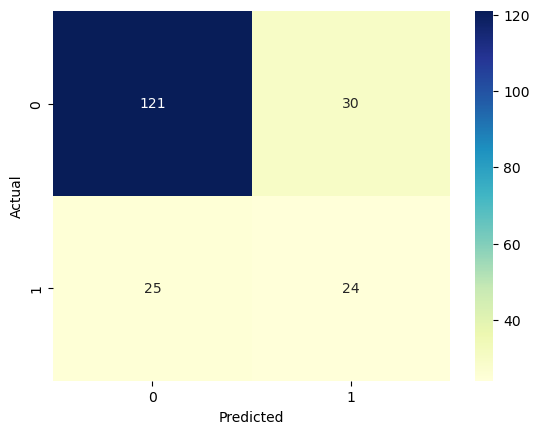

In [9]:
cm = confusion_matrix(y_test, lr.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [10]:
ensemble = VotingClassifier(
    estimators=[
        ('LR', lr),
        ('MNB', mnb),
        #('SVM', svc)
    ],
    voting='hard'
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)

print("Ensemble Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Ensemble Accuracy: 0.755
              precision    recall  f1-score   support

           0       0.76      1.00      0.86       151
           1       0.00      0.00      0.00        49

    accuracy                           0.76       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.57      0.76      0.65       200

